# 4. Production Pipelines with Imbalanced Data (`imblearn.pipeline.Pipeline`)

This notebook covers:
1. **The Critical Trap of `sklearn.pipeline.Pipeline` with Resampling**: Why Scikit-Learn pipelines cannot execute SMOTE and fail during cross-validation.
2. **The Correct Solution (`imblearn.pipeline.Pipeline`)**: Automatically applying SMOTE strictly during `.fit()` on training folds while leaving evaluation/test data un-resampled.
3. **Unified Preprocessing + Synthetic Oversampling + Classifier**:
   - `ColumnTransformer` (Scaling + Encoding)
   - `SMOTE` (Synthetic Generation on encoded numeric vectors)
   - `RandomForestClassifier`
4. **Proper Skewed Metrics**: Moving beyond standard ROC-AUC to Precision-Recall AUC (`PR-AUC` / Average Precision).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, PrecisionRecallDisplay, average_precision_score

# Critical Import: Use imblearn's Pipeline, NOT sklearn's Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# 1. Create realistic tabular dataset with mixed features and extreme 95:5 imbalance
X_raw, y_raw = make_classification(
    n_samples=1200,
    n_features=4,
    n_informative=3,
    n_redundant=1,
    weights=[0.95, 0.05],  # 95% Legit (0), 5% Fraud (1)
    random_state=42
)

# Convert to DataFrame with mixed data types (Numerical + Categorical)
df = pd.DataFrame(X_raw, columns=['Transaction_Amount', 'Account_Age_Days', 'Login_Attempts', 'Risk_Score'])
df['Device_Type'] = np.random.choice(['Mobile', 'Desktop', 'Tablet'], size=len(df), p=[0.6, 0.3, 0.1])
df['Is_Fraud'] = y_raw

print("=== 1. RAW DATASET OVERVIEW ===")
display(df.head())
print("\nClass Distribution:")
display(df['Is_Fraud'].value_counts().to_frame(name='Count').assign(
    Proportion=df['Is_Fraud'].value_counts(normalize=True).map('{:.1%}'.format)
))

=== 1. RAW DATASET OVERVIEW ===


,Transaction_Amount,Account_Age_Days,Login_Attempts,Risk_Score,Device_Type,Is_Fraud
0,-1.346072,0.138080,0.145693,0.971393,Mobile,0
1,0.046221,-2.411918,-2.107142,-0.327620,Desktop,1
2,-0.717352,-1.404037,-0.852919,-0.782067,Tablet,0
3,-1.009276,-1.353631,-0.741509,-0.761564,Mobile,0
4,-0.934501,-1.361743,-1.310873,0.928906,Tablet,0



Class Distribution:


,Count,Proportion
Is_Fraud,,
0,1136,94.7%
1,64,5.3%


---
## Step 1: Stratified Train / Test Split

Split the dataset into an 80/20 train/test split with stratification enabled.

In [2]:
X = df.drop(columns=['Is_Fraud']).copy()
y = df['Is_Fraud'].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Train samples: {len(X_train)} (Fraud: {y_train.sum()})")
print(f"Test samples:  {len(X_test)} (Fraud: {y_test.sum()})")

Train samples: 960 (Fraud: 51)
Test samples:  240 (Fraud: 13)


---
## Step 2: Build the Preprocessor (`ColumnTransformer`)

SMOTE relies on Euclidean distance ($k$-Nearest Neighbors), so:
* All categorical columns must be converted to numbers (`OneHotEncoder`).
* All numerical columns must be on the same scale (`StandardScaler`).

In [3]:
preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(sparse_output=False, drop='first'), ['Device_Type']),
    ('num', StandardScaler(), ['Transaction_Amount', 'Account_Age_Days', 'Login_Attempts', 'Risk_Score'])
], remainder = 'passthrough')

---
## Step 3: Assemble the End-to-End Imbalanced Pipeline

> **Why `imblearn.pipeline.Pipeline`?**
> Standard `sklearn.pipeline.Pipeline` requires every intermediate step to implement `.transform()`.
> Resamplers like `SMOTE` implement `.fit_resample()`, not `.transform()`.
> `imblearn.pipeline.Pipeline` seamlessly applies SMOTE **only during `.fit()`** on training folds, and automatically **bypasses SMOTE during `.predict()` or test evaluation**.

In [4]:
pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('sampler', SMOTE(random_state=42, k_neighbors=5)),
    ('classifier', RandomForestClassifier(random_state=42, n_estimators=100))
])

pipeline.fit(X_train,y_train)
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

print("=== TEST SET PERFORMANCE (IMBLEARN PIPELINE) ===")
print(classification_report(y_test, y_pred, target_names=['Legit (0)', 'Fraud (1)']))

=== TEST SET PERFORMANCE (IMBLEARN PIPELINE) ===
              precision    recall  f1-score   support

   Legit (0)       0.98      0.98      0.98       227
   Fraud (1)       0.67      0.62      0.64        13

    accuracy                           0.96       240
   macro avg       0.82      0.80      0.81       240
weighted avg       0.96      0.96      0.96       240



---
## Step 4: Leak-Free Cross-Validation

Using `imblearn.pipeline.Pipeline` inside `cross_val_score` guarantees that SMOTE is executed **inside each training fold independently**, preventing synthetic samples from leaking into validation folds.

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Evaluate using average precision (PR-AUC), the industry standard for severe skew
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='average_precision')

print(f"5-Fold Cross-Validated PR-AUC Scores: {cv_scores.round(3)}")
print(f"Mean PR-AUC: {cv_scores.mean():.3f} (± {cv_scores.std():.3f})")

5-Fold Cross-Validated PR-AUC Scores: [0.711 0.63  0.561 0.806 0.783]
Mean PR-AUC: 0.698 (± 0.092)


---
## Step 5: Precision-Recall Curve Visualization

For highly imbalanced data, ROC curves present an overly optimistic score because False Positive Rate stays small when Class 0 is massive. The **Precision-Recall Curve** provides the true performance profile across all probability thresholds.

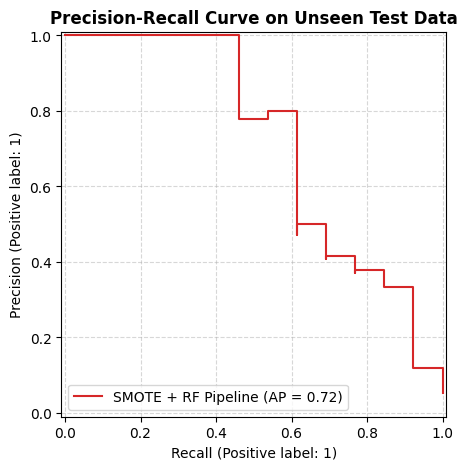

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))

display_pr = PrecisionRecallDisplay.from_estimator(
    pipeline, X_test, y_test,
    ax=ax,
    name="SMOTE + RF Pipeline",
    color="#d62728"
)

ax.set_title("Precision-Recall Curve on Unseen Test Data", fontsize=12, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.5)
plt.show()

---
## Key Summary of Production Rules

1. **Always use `imblearn.pipeline.Pipeline`** when using resampling methods like SMOTE, ADASYN, or RandomUnderSampler.
2. **Scale and encode features before SMOTE**: Distance calculations require numerical, normalized inputs.
3. **Never resample the test set**: Evaluate performance strictly on the authentic, imbalanced production distribution.
4. **Primary evaluation metric**: Prioritize **PR-AUC (Average Precision)** and **Precision-Recall tradeoffs** over ROC-AUC and Accuracy.

## Cell 10 explained:
```python 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='average_precision')
```
### What is StratifiedKFold?
Standard KFold randomly splits data into 5 chunks (folds).
- In a 95:5 imbalanced dataset, random splitting might create a fold with zero fraud cases, completely breaking training or evaluation for that fold.
- StratifiedKFold guarantees proportions: It forces every single fold to maintain the exact 95% Legit vs. 5% Fraud ratio.

### What Happens Inside cross_val_score(pipeline, ...)?
It repeats this loop 5 times:

1) Takes 4 folds for training, 1 fold for validation.
2) Runs ColumnTransformer (fit on 4 folds).
3) Runs SMOTE strictly inside the 4 training folds (the validation fold remains 100% untouched and authentic).
4) Trains the RandomForestClassifier.
5) Evaluates the model on the untouched validation fold.

This guarantees zero data leakage.

## Cell 13 explained & The Difference Between ROC-AUC and PR-AUC
Why ROC-AUC Fails on Imbalanced Data:

- ROC-AUC plots True Positive Rate (Recall) against False Positive Rate (FPR):
$$\text{FPR} = \frac{\text{False Positives}}{\text{Real Legitimate Samples}}$$

- If you have 10,000 Legit cases and the model triggers 100 False Alarms:
$$\text{FPR} = \frac{100}{10,000} = 0.01 \quad (1\%)$$

- The ROC curve looks near-perfect ($\text{ROC-AUC} \approx 0.98$), giving a false sense of security, even though 100 false alarms might overwhelm an operations team.

### Why PR-AUC (Precision-Recall AUC) is the Industry Standard for Imbalance:
- PR-AUC completely ignores True Negatives (the massive pool of majority cases).
- It plots Precision (how clean are the fraud alarms?) vs. Recall (did we catch the fraud?).
- If the model triggers 100 false alarms to catch 10 fraud cases, Precision drops to $9\%$, and the PR-AUC curve immediately collapses, accurately exposing the model's weakness.

## Summary Checklist
- Use imblearn.pipeline.Pipeline whenever resampling steps are involved.
- Use StratifiedKFold so every cross-validation slice has minority samples.
- Evaluate severely skewed datasets with PR-AUC (Average Precision), not standard Accuracy or ROC-AUC.

Here is some more detailed epxlanation of the code:

### 1. Why Not Just Add `.fit_resample()` to Scikit-Learn's Pipeline?

In Scikit-Learn, every pipeline intermediate step's `.transform()` and `.fit_transform()` methods **only accept `X` and return a modified `X`**:
Python

```
# Standard scikit-learn intermediate contract
X_transformed = step.fit_transform(X, y)
```

Notice that `y` is passed purely for guidance, but **`y` itself is never returned or modified**.

Resampling techniques like SMOTE or RandomUnderSampler must create or drop rows from **both $X$ and $y$** simultaneously. If you drop or add rows to $X$, the number of rows in $X$ and $y$ immediately misaligns:

$$\text{len}(X_{\text{resampled}}) \neq \text{len}(y)$$
Scikit-Learn's internal pipeline design strictly forbids modifying the target vector $y$ midway through the chain. The developers of `imbalanced-learn` designed `imblearn.pipeline.Pipeline` specifically to support passing and returning $(X, y)$ tuples via `.fit_resample()`, while disabling that step during inference (`predict()`).
### 2. `StratifiedKFold`: Folds, Naming, Shuffle, and `random_state=42`

- **Validation vs. Testing:**
    - In the context of cross-validation, the held-out fold is formally called the **validation fold** (or validation split).
    - We reserve the term **test set** for the final, untouched evaluation set (the 20% holdout created at the start with `train_test_split`).
- **`shuffle=True`:**
    - If your original CSV is sorted (e.g., all legitimate transactions first, all fraud cases at the bottom), standard splitting without shuffling creates skewed or entirely one-sided folds.
    - Setting `shuffle=True` shuffles the row indices before partitioning into the 5 folds.
- **`random_state=42`:** 
    - Setting a seed number guarantees **reproducibility**—you get the exact same split shuffle every time you rerun the notebook.
    - **Why 42?** There is no mathematical significance; it is a long-standing pop-culture reference from Douglas Adams' _The Hitchhiker's Guide to the Galaxy_ ("the answer to the ultimate question of life, the universe, and everything"). Any integer (such as `0`, `1`, or `123`) functions identically.

### 3. Verification: What Happens Inside `cross_val_score(pipeline, ...)`

Your breakdown is largely on point, with one key step added: **SMOTE happens inside that training block as well.**

Here is the exact cycle repeated 5 times across the 5 folds:

Plaintext

```
[ Fold 1 ] [ Fold 2 ] [ Fold 3 ] [ Fold 4 ] ──> Training Data (4 Folds)
[ Fold 5 ]                                  ──> Validation Data (1 Fold)
```

1. **Preprocessing:** Fit `ColumnTransformer` (scaling & encoding) on the 4 training folds only. Transform the 4 training folds and the 1 validation fold.
2. **Resampling:** Run SMOTE **strictly on the 4 training folds** to balance them. The validation fold is untouched.
3. **Model Training:** Train the `RandomForestClassifier` on the balanced training data.
4. **Validation Scoring:** Predict on the raw, untouched validation fold and record the PR-AUC score.
5. Rotate to the next fold and repeat.
### 4. Untangling ROC-AUC vs. PR-AUC (With Concrete Definitions)

In binary fraud detection, the conventions are:
- **Positive ($1$):** Fraud (Rare minority class)
- **Negative ($0$):** Legit (Massive majority class)

Here are the key metrics stripped down:
- **True Positive Rate (Recall / Sensitivity):**
$$\text{TPR} = \frac{\text{Fraud caught}}{\text{All actual Fraud}}$$

*Answers: "Out of all real fraud cases, how many did the model detect?"*

- **False Positive Rate (FPR — Used in ROC):**

$$\text{FPR} = \frac{\text{False Alarms}}{\text{All actual Legit}}$$

*The flaw on imbalanced data:* If there are $100,000$ legit transactions and the model generates $500$ false alarms:

    $$\text{FPR} = \frac{500}{100,000} = 0.005 \quad (0.5\%)$$

Because the denominator ($\text{All Legit}$) is huge, the ROC curve looks virtually flawless even with hundreds of false alarms.

- **Precision (Used in PR-AUC):**

$$\text{Precision} = \frac{\text{Real Fraud Caught}}{\text{Total Fraud Alarms Raised (Real Fraud + False Alarms)}}$$

*Answers: "When the model flags a transaction as fraud, how often is it actually right?"*
    
If the model caught $50$ frauds but raised $500$ false alarms:

    $$\text{Precision} = \frac{50}{50 + 500} = \frac{50}{550} \approx 9.1\%$$
    

The PR-AUC curve evaluates this $9.1\%$ Precision against Recall, showing you the real operational cost of those false alarms without letting massive True Negatives mask the errors.

### 5. Summary Reference

|**Scenario**|**Preferred Approach**|**Why**|
|---|---|---|
|**Pipeline choice**|`imblearn.pipeline.Pipeline`|Supports `.fit_resample()` without breaking Scikit-Learn's 1-input contract.|
|**Cross-validation strategy**|`StratifiedKFold(shuffle=True)`|Preserves exact minority-to-majority ratios across every split.|
|**Evaluation metric for skew**|**PR-AUC (Average Precision)**|Directly tracks False Positives relative to actual positive detections.|